# Week 2 Progress
## Intelligent Customer Retention Analytics Using Machine Learning

**Abhimanue Monichan Paliyathuchirayil (5148147)**  
**Jeevitha Murugan (5148291)**  
**Md Mahin Hasan (5148365)**  

Department of Computer Science, Algoma University  
COSC-5806-W03-2026

---
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.preprocessing import LabelEncoder, StandardScaler

print('Libraries imported successfully.')

Libraries imported successfully.


---
## 2. Load Dataset

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head()

Dataset shape: (7043, 21)
Rows: 7043, Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

---
## 3. Data Preprocessing

### 3.1 Handle Missing Values in TotalCharges

In [4]:
# TotalCharges contains whitespace strings for customers with tenure=0
# Convert to numeric - whitespace becomes NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing_count = df['TotalCharges'].isna().sum()
print(f'Number of missing TotalCharges values: {missing_count}')

# Display the affected records
print('\nRecords with missing TotalCharges:')
df[df['TotalCharges'].isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Number of missing TotalCharges values: 11

Records with missing TotalCharges:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [5]:
# Fill missing TotalCharges with column median (robust to outliers)
median_value = df['TotalCharges'].median()
print(f'TotalCharges median used for imputation: {median_value:.3f}')

df['TotalCharges'].fillna(median_value, inplace=True)

print(f'Missing values after imputation: {df["TotalCharges"].isna().sum()}')

TotalCharges median used for imputation: 1397.475
Missing values after imputation: 0


C:\Users\DELL LAPTOP\AppData\Local\Temp\ipykernel_41840\2622772050.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(median_value, inplace=True)


### 3.2 Encode the Target Column (Churn)

In [6]:
# Label encode Churn: Yes -> 1, No -> 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Churn encoding complete.')
print(df['Churn'].value_counts())
print(f'\nChurn rate: {df["Churn"].mean()*100:.1f}%')

Churn encoding complete.
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


### 3.3 Label Encoding — Binary Categorical Features

In [7]:
# Binary features with Yes/No or Male/Female values
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies']

le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f'{col}: encoded')

print('\nBinary label encoding complete.')

gender: encoded
Partner: encoded
Dependents: encoded
PhoneService: encoded
PaperlessBilling: encoded
MultipleLines: encoded
OnlineSecurity: encoded
OnlineBackup: encoded
DeviceProtection: encoded
TechSupport: encoded
StreamingTV: encoded
StreamingMovies: encoded

Binary label encoding complete.


### 3.4 One-Hot Encoding — Multi-Class Categorical Features

In [8]:
# Multi-class nominal features — use One-Hot Encoding to avoid implied ordinal relationship
multiclass_cols = ['InternetService', 'Contract', 'PaymentMethod']

print('Unique values before encoding:')
for col in multiclass_cols:
    print(f'  {col}: {df[col].unique().tolist()}')

df = pd.get_dummies(df, columns=multiclass_cols, drop_first=False)

print(f'\nDataset shape after one-hot encoding: {df.shape}')

Unique values before encoding:
  InternetService: ['DSL', 'Fiber optic', 'No']
  Contract: ['Month-to-month', 'One year', 'Two year']
  PaymentMethod: ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']

Dataset shape after one-hot encoding: (7043, 28)


### 3.5 Drop Irrelevant Column

In [9]:
# customerID is a unique identifier and carries no predictive value
df.drop(columns=['customerID'], inplace=True)
print(f'Dataset shape after dropping customerID: {df.shape}')

Dataset shape after dropping customerID: (7043, 27)


### 3.6 Feature Normalization — StandardScaler

In [10]:
# Standardize numerical features to zero mean and unit variance
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print('Before scaling:')
print(df[numerical_cols].describe().round(2))

scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print('\nAfter scaling (mean~0, std~1):')
print(df[numerical_cols].describe().round(3))

Before scaling:
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2281.92
std      24.56           30.09       2265.27
min       0.00           18.25         18.80
25%       9.00           35.50        402.22
50%      29.00           70.35       1397.48
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80

After scaling (mean~0, std~1):
         tenure  MonthlyCharges  TotalCharges
count  7043.000        7043.000      7043.000
mean     -0.000          -0.000        -0.000
std       1.000           1.000         1.000
min      -1.318          -1.546        -0.999
25%      -0.952          -0.973        -0.830
50%      -0.137           0.186        -0.390
75%       0.921           0.834         0.664
max       1.614           1.794         2.827


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Churn Distribution

C:\Users\DELL LAPTOP\AppData\Local\Temp\ipykernel_41840\95560308.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_eda['TotalCharges'].fillna(df_eda['TotalCharges'].median(), inplace=True)


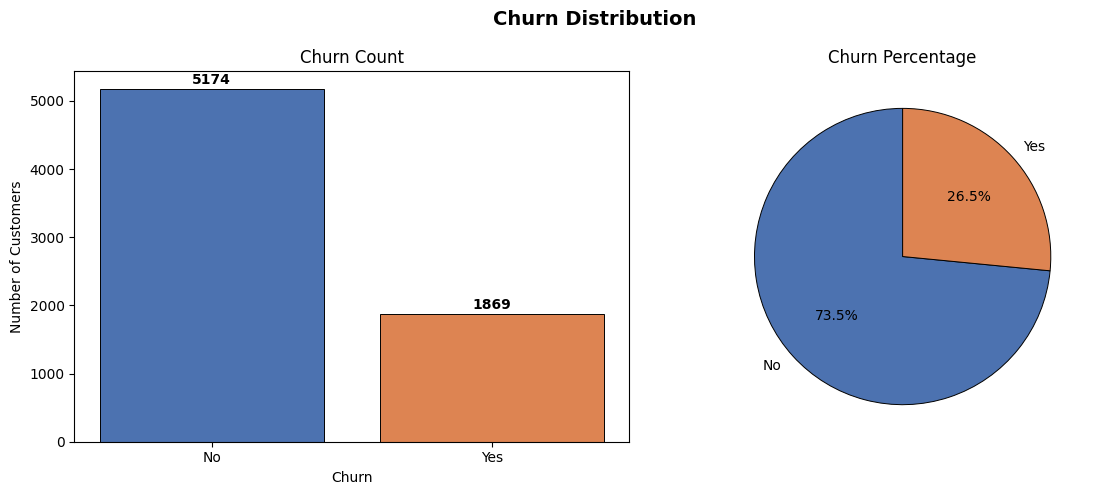

Retained (No):  5174 customers (73.5%)
Churned  (Yes): 1869 customers (26.5%)

Note: Dataset is imbalanced. Class weighting or resampling (e.g. SMOTE) will be considered in Week 3.


In [11]:
# Reload original for EDA visualizations (pre-encoding for readability)
df_eda = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')
df_eda['TotalCharges'].fillna(df_eda['TotalCharges'].median(), inplace=True)

churn_counts = df_eda['Churn'].value_counts()
churn_pct = df_eda['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Churn Distribution', fontsize=14, fontweight='bold')

# Count plot
colors = ['#4C72B0', '#DD8452']
bars = axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, str(val),
                 ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 0.7})
axes[1].set_title('Churn Percentage')

plt.tight_layout()
plt.show()

print(f'Retained (No):  {churn_counts["No"]} customers ({churn_pct["No"]:.1f}%)')
print(f'Churned  (Yes): {churn_counts["Yes"]} customers ({churn_pct["Yes"]:.1f}%)')
print('\nNote: Dataset is imbalanced. Class weighting or resampling (e.g. SMOTE) will be considered in Week 3.')

### 4.2 Tenure Distribution by Churn

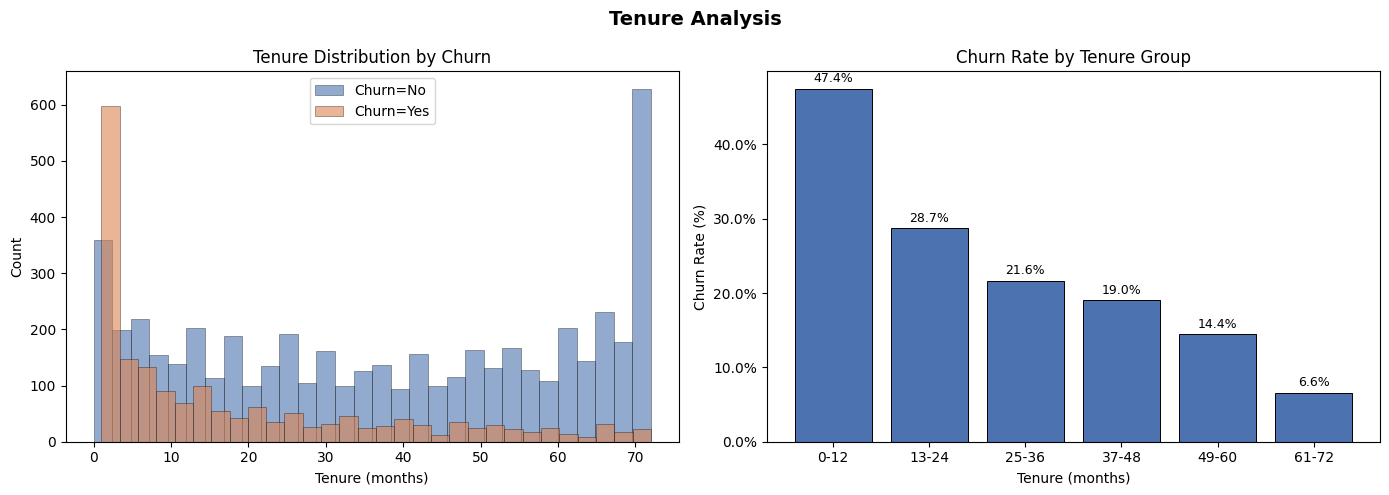

Churn rate for tenure 0-12 months: 47.4%
Overall churn rate:                26.5%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tenure Analysis', fontsize=14, fontweight='bold')

# Histogram of tenure by churn
for label, color in zip(['No', 'Yes'], ['#4C72B0', '#DD8452']):
    axes[0].hist(df_eda[df_eda['Churn'] == label]['tenure'],
                 bins=30, alpha=0.6, label=f'Churn={label}', color=color, edgecolor='black', linewidth=0.4)
axes[0].set_title('Tenure Distribution by Churn')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Churn rate by tenure bucket
bins = [0, 12, 24, 36, 48, 60, 72]
labels_b = ['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
df_eda['tenure_group'] = pd.cut(df_eda['tenure'], bins=bins, labels=labels_b, include_lowest=True)
churn_by_tenure = df_eda.groupby('tenure_group', observed=True)['Churn'].apply(lambda x: (x=='Yes').mean()*100)

bars = axes[1].bar(churn_by_tenure.index, churn_by_tenure.values, color='#4C72B0', edgecolor='black', linewidth=0.7)
axes[1].set_title('Churn Rate by Tenure Group')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, churn_by_tenure.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

short = df_eda[df_eda['tenure'] <= 12]
print(f'Churn rate for tenure 0-12 months: {(short["Churn"]=="Yes").mean()*100:.1f}%')
print(f'Overall churn rate:                {(df_eda["Churn"]=="Yes").mean()*100:.1f}%')

### 4.3 Monthly Charges Distribution by Churn

C:\Users\DELL LAPTOP\AppData\Local\Temp\ipykernel_41840\556856976.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([churn_no, churn_yes], labels=['Retained (No)', 'Churned (Yes)'],


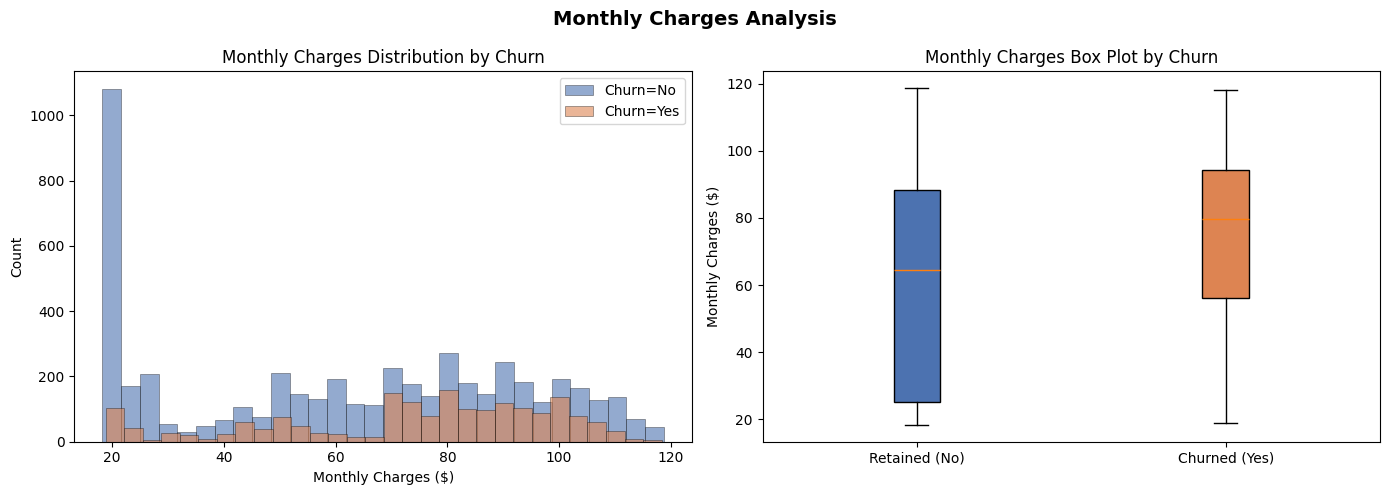

Avg MonthlyCharges — Churned:   $74.44
Avg MonthlyCharges — Retained:  $61.27


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Monthly Charges Analysis', fontsize=14, fontweight='bold')

# Histogram
for label, color in zip(['No', 'Yes'], ['#4C72B0', '#DD8452']):
    axes[0].hist(df_eda[df_eda['Churn'] == label]['MonthlyCharges'],
                 bins=30, alpha=0.6, label=f'Churn={label}', color=color, edgecolor='black', linewidth=0.4)
axes[0].set_title('Monthly Charges Distribution by Churn')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
churn_no = df_eda[df_eda['Churn']=='No']['MonthlyCharges']
churn_yes = df_eda[df_eda['Churn']=='Yes']['MonthlyCharges']
bp = axes[1].boxplot([churn_no, churn_yes], labels=['Retained (No)', 'Churned (Yes)'],
                     patch_artist=True)
bp['boxes'][0].set_facecolor('#4C72B0')
bp['boxes'][1].set_facecolor('#DD8452')
axes[1].set_title('Monthly Charges Box Plot by Churn')
axes[1].set_ylabel('Monthly Charges ($)')

plt.tight_layout()
plt.show()

print(f'Avg MonthlyCharges — Churned:   ${churn_yes.mean():.2f}')
print(f'Avg MonthlyCharges — Retained:  ${churn_no.mean():.2f}')

### 4.4 Contract Type vs Churn Rate

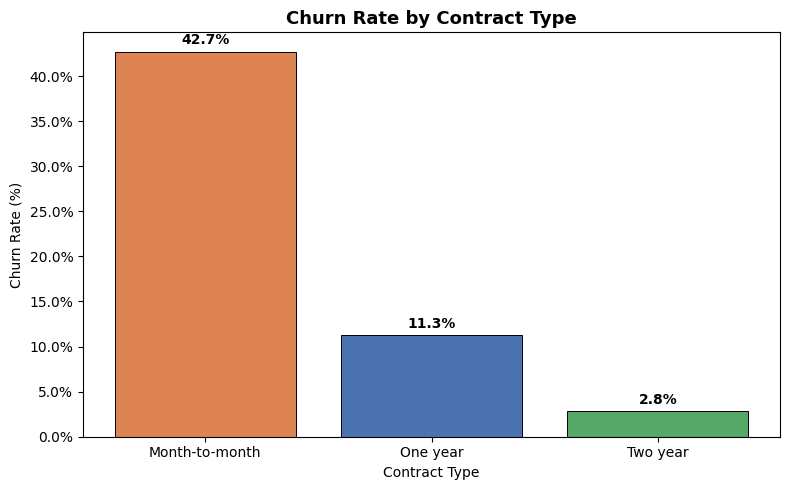

      Contract  Churn Rate (%)
Month-to-month       42.709677
      One year       11.269518
      Two year        2.831858


In [14]:
contract_churn = df_eda.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate (%)']

fig, ax = plt.subplots(figsize=(8, 5))
colors_c = ['#DD8452', '#4C72B0', '#55A868']
bars = ax.bar(contract_churn['Contract'], contract_churn['Churn Rate (%)'],
              color=colors_c, edgecolor='black', linewidth=0.7)
ax.set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, contract_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print(contract_churn.to_string(index=False))

### 4.5 Categorical Feature Analysis — Internet Service & Tech Support

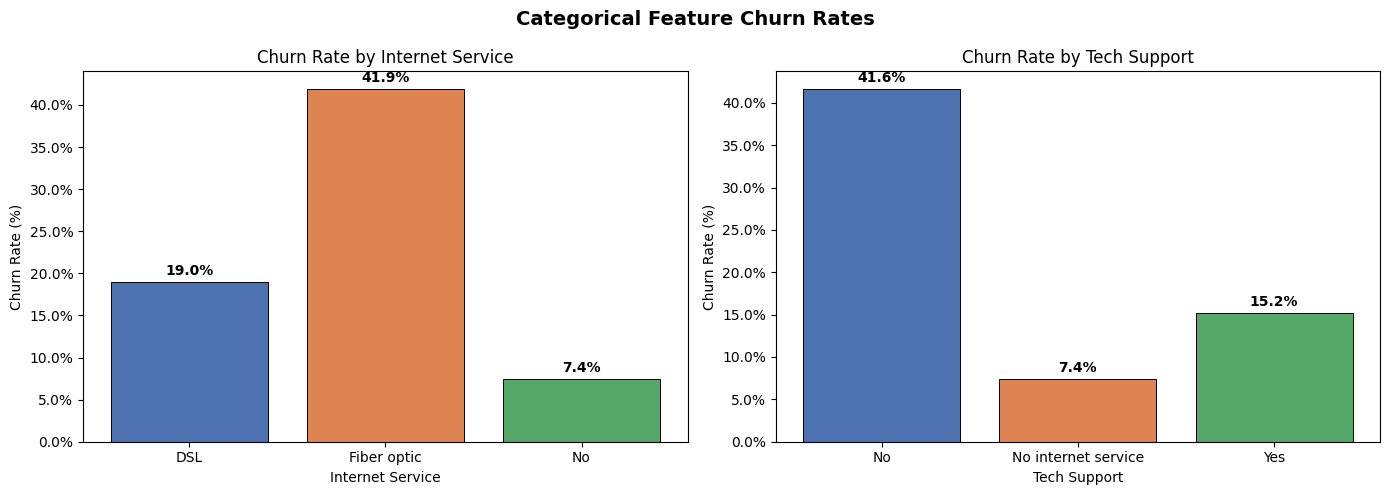

Internet Service Churn Rate:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4

Tech Support Churn Rate:
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Categorical Feature Churn Rates', fontsize=14, fontweight='bold')

# Internet Service
internet_churn = df_eda.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
bars1 = axes[0].bar(internet_churn.index, internet_churn.values,
                    color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black', linewidth=0.7)
axes[0].set_title('Churn Rate by Internet Service')
axes[0].set_xlabel('Internet Service')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars1, internet_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# Tech Support
tech_churn = df_eda.groupby('TechSupport')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
bars2 = axes[1].bar(tech_churn.index, tech_churn.values,
                    color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black', linewidth=0.7)
axes[1].set_title('Churn Rate by Tech Support')
axes[1].set_xlabel('Tech Support')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars2, tech_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print('Internet Service Churn Rate:')
print(internet_churn.round(1).to_string())
print('\nTech Support Churn Rate:')
print(tech_churn.round(1).to_string())

### 4.6 Correlation Heatmap

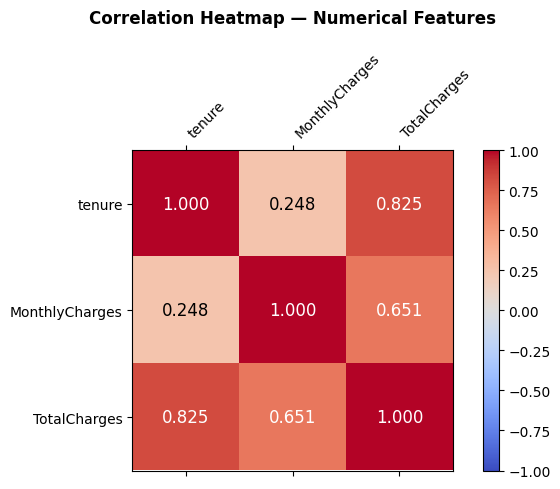

Correlation Matrix:
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.825
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.825           0.651         1.000

Key Finding: TotalCharges is highly correlated with tenure (0.826) and MonthlyCharges (0.651).
This multicollinearity will be addressed during feature selection in Week 3.


In [16]:
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df_eda[num_features].corr()

fig, ax = plt.subplots(figsize=(7, 5))

cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

ax.set_xticks(range(len(num_features)))
ax.set_yticks(range(len(num_features)))
ax.set_xticklabels(num_features, rotation=45, ha='left')
ax.set_yticklabels(num_features)
ax.set_title('Correlation Heatmap — Numerical Features', pad=20, fontweight='bold')

for i in range(len(num_features)):
    for j in range(len(num_features)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.3f}',
                ha='center', va='center', fontsize=12,
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.6 else 'black')

plt.tight_layout()
plt.show()

print('Correlation Matrix:')
print(corr_matrix.round(3))
print('\nKey Finding: TotalCharges is highly correlated with tenure (0.826) and MonthlyCharges (0.651).')
print('This multicollinearity will be addressed during feature selection in Week 3.')

---
## 5. Summary of Preprocessed Dataset

In [17]:
print('=== Final Preprocessed Dataset ===')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isna().sum().sum()}')
print(f'\nColumns ({len(df.columns)}):')
print(df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

=== Final Preprocessed Dataset ===
Shape: (7043, 27)
Missing values: 0

Columns (27):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

First 5 rows:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,0,2,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,0.066327,1,0,2,0,2,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,-1.236724,1,0,2,2,0,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,0.514251,0,1,2,0,2,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,-1.236724,1,0,0,0,0,...,False,True,False,True,False,False,False,False,True,False
